In [17]:
import sirf
from sirf.Utilities import existing_filepath
from sirf.Utilities import error
from sirf.Utilities import show_3D_array
from sirf.Gadgetron import examples_data_path
from sirf.Gadgetron import AcquisitionData, ImageData
from sirf.Gadgetron import AcquisitionModel
from sirf.Gadgetron import AcquisitionDataProcessor
from sirf.Gadgetron import CartesianGRAPPAReconstructor
from sirf.Gadgetron import CoilSensitivityData
from sirf.Gadgetron import preprocess_acquisition_data
from sirf.Gadgetron import FullySampledReconstructor


from cil.optimisation.functions import LeastSquares
from cil.optimisation.functions import ZeroFunction
from cil.optimisation.algorithms import FISTA, CGLS, GD
from cil.plugins.ccpi_regularisation.functions import FGP_TV#, TGV, LLT_ROF, Diff4th
from cil.framework import DataContainer as cilDataContainer
from cil.optimisation.operators import LinearOperator

import numpy
import time

import matplotlib.pyplot as plt
import os

In [42]:
fname = 'work/data/h5/1meas_MID00619_FID129157_AI_RECON_SEQD_512_GF4_AX_RL_mod.h5'
#fname = 'work/data/h5/1meas_MID00614_FID129152_CONVENTIONAL_RECON_SEQD_GF2_AX_RL_mod.h5'

In [43]:
acq_data = AcquisitionData(fname)

reading from work/data/h5/1meas_MID00619_FID129157_AI_RECON_SEQD_512_GF4_AX_RL_mod.h5 using ignore mask 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 

Started reading acquisitions from work/data/h5/1meas_MID00619_FID129157_AI_RECON_SEQD_512_GF4_AX_RL_mod.h5
0%..10%..20%..30%..40%..50%..60%..70%..80%..90%..100%..
Finished reading acquisitions from work/data/h5/1meas_MID00619_FID129157_AI_RECON_SEQD_512_GF4_AX_RL_mod.h5


In [44]:
acq_data = preprocess_acquisition_data(acq_data)

ignoring acquisition 0
Message received with ID: 5
Input stream has terminated


In [45]:
recon = FullySampledReconstructor()
recon.set_input(acq_data)
recon.process()

Message received with ID: 5
Input stream has terminated


Text(0.5, 1.0, 'Reconstructed image data (magnitude)')

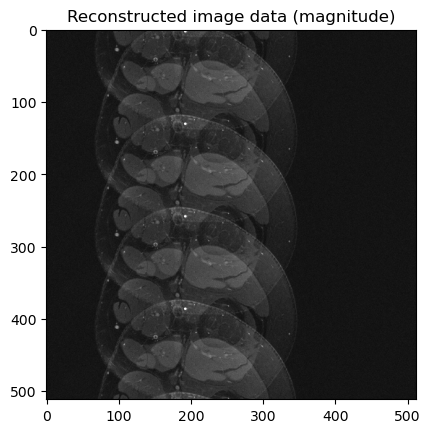

In [46]:
image_data = recon.get_output()
image_array = abs(image_data.as_array())
image_array = image_array/image_array.max()

plt.figure(1)
plt.set_cmap('gray')
plt.imshow(image_array[0,:,:], vmin=0, vmax=0.7)
plt.title('Reconstructed image data (magnitude)') 


In [47]:
csm = CoilSensitivityData()
csm.smoothness = 100
csm.calculate(acq_data)

In [48]:
E = AcquisitionModel(acqs=acq_data, imgs=csm)
E.set_coil_sensitivity_maps(csm)
x_inverse = E.inverse(acq_data)

In [49]:
# We set up our AcquisitionModel
E = AcquisitionModel(acqs=acq_data, imgs=x_inverse)
E.set_coil_sensitivity_maps(csm)

# Use the result of the inverse as our starting point
x_init = x_inverse.clone()

# Define our objective/loss function as least squares between Ex and y
f = LeastSquares(E, acq_data, c=1)

G = ZeroFunction()

# Set up FISTA
fista = FISTA(initial=x_init.fill(0.0), f=f, g=G)
fista.update_objective_interval = 5


# Run FISTA for least squares
fista.run(10)

  0%|          | 0/10 [00:00<?, ?it/s]

Text(0.5, 1.0, 'Reconstructed image data (magnitude)')

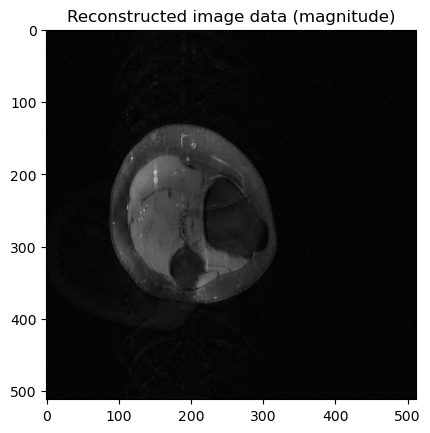

In [61]:
image_data = fista.get_output()
image_array = abs(image_data.as_array())
image_array = image_array/image_array.max()

plt.figure(1)
plt.set_cmap('gray')
plt.imshow(image_array[15,:,:], vmin=0, vmax=0.7)
plt.title('Reconstructed image data (magnitude)') 

In [55]:
image_array.shape

(18, 512, 512)